# Tyre Degradation Analysis
How much slower do laps get as tyres age, and how does this differ between Soft, Medium and Hard compounds?

## 1. Setup

In [1]:
import os
import fastf1
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

os.makedirs("../f1_cache", exist_ok=True)
fastf1.Cache.enable_cache("../f1_cache")

## 2. Load one race
Using the 2025 Italian Grand Prix (Monza) to explore the data before the full season CSVs are ready.

In [2]:
session = fastf1.get_session(2025, "Monza", "R")
session.load(telemetry=False)
laps = session.laps
print(len(laps), "laps loaded")

core           INFO 	Loading data for Italian Grand Prix - Race [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	Failed to perform lap accuracy check - all laps marked as inaccurate (driver 27)
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '4', '81', '16', '63', '44', '23', '5', '12', '6', '55', '87', '22', '30', '31', '10', '43', '18', '14', '27']


974 laps loaded


## 3. Explore the tyre columns
- `Compound`: SOFT, MEDIUM or HARD
- `TyreLife`: how many laps that set of tyres has done
- `Stint`: which stint the driver is on (1 = first set, 2 = after the first pit stop, ...)

In [3]:
laps[["Driver", "LapNumber", "LapTime", "Compound", "TyreLife", "Stint", "PitInTime", "TrackStatus"]].head(20)

,Driver,LapNumber,LapTime,Compound,TyreLife,Stint,PitInTime,TrackStatus
0,VER,1.0,0 days 00:01:27.159000,MEDIUM,1.0,1.0,NaT,1
1,VER,2.0,0 days 00:01:24.859000,MEDIUM,2.0,1.0,NaT,1
2,VER,3.0,0 days 00:01:23.512000,MEDIUM,3.0,1.0,NaT,1
3,VER,4.0,0 days 00:01:23.262000,MEDIUM,4.0,1.0,NaT,1
4,VER,5.0,0 days 00:01:23.588000,MEDIUM,5.0,1.0,NaT,1
5,VER,6.0,0 days 00:01:23.576000,MEDIUM,6.0,1.0,NaT,1
6,VER,7.0,0 days 00:01:23.310000,MEDIUM,7.0,1.0,NaT,1
7,VER,8.0,0 days 00:01:23.139000,MEDIUM,8.0,1.0,NaT,1
8,VER,9.0,0 days 00:01:23.101000,MEDIUM,9.0,1.0,NaT,1
9,VER,10.0,0 days 00:01:23.088000,MEDIUM,10.0,1.0,NaT,1


## 4. Clean the laps
Remove pit in/out laps, safety car and yellow flag laps, unusually slow laps, and laps with no time.

In [4]:
clean = laps.pick_wo_box()           # remove pit in/out laps
clean = clean.pick_track_status("1") # green flag only (no safety car)
clean = clean.pick_quicklaps()       # remove laps slower than 107% of the fastest
clean = clean[clean["LapTime"].notna()].copy()
clean["LapTimeSeconds"] = clean["LapTime"].dt.total_seconds()

print(len(laps), "->", len(clean), "laps after cleaning")

974 -> 894 laps after cleaning


## 5. Lap time vs tyre age
**Note:** cars also get faster during a race as fuel burns off, which works against tyre wear. Raw plots can therefore understate degradation. This is handled later by including `LapNumber` in the regression.

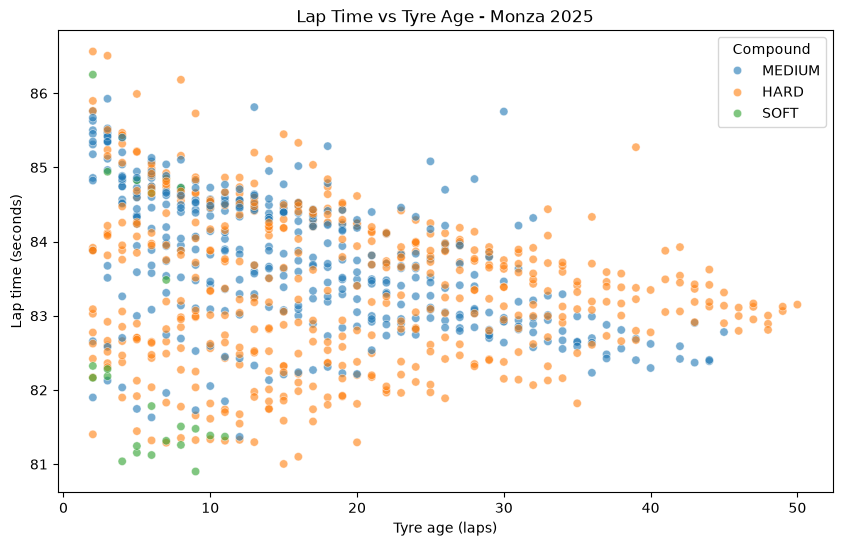

In [5]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=clean, x="TyreLife", y="LapTimeSeconds", hue="Compound", alpha=0.6)
plt.title("Lap Time vs Tyre Age - Monza 2025")
plt.xlabel("Tyre age (laps)")
plt.ylabel("Lap time (seconds)")
plt.show()

## 6. Full dataset (5 races, 2025)
Loading the merged laps + weather data from the data pipeline.

In [6]:
df = pd.read_csv("../data/processed/cleaned_laps.csv")
print(df.shape)
print(df["Race"].value_counts())
df[["Race", "Driver", "LapNumber", "LapTime_s", "Compound", "TyreLife", "TrackTemp", "Rainfall"]].head()

(5305, 43)
Race
Monaco         1423
Bahrain        1115
Suzuka         1059
Monza           974
Silverstone     734
Name: count, dtype: int64


,Race,Driver,LapNumber,LapTime_s,Compound,TyreLife,TrackTemp,Rainfall
0,Bahrain,PIA,1.0,98.693,SOFT,4.0,31.9,False
1,Bahrain,RUS,1.0,99.582,SOFT,4.0,31.9,False
2,Bahrain,NOR,1.0,100.424,SOFT,4.0,31.9,False
3,Bahrain,LEC,1.0,101.332,MEDIUM,1.0,31.9,False
4,Bahrain,GAS,1.0,102.050,SOFT,4.0,31.9,False


In [7]:
clean = df[
    df["PitInTime"].isna()                                      # not a pit-in lap
    & df["PitOutTime"].isna()                                   # not a pit-out lap
    & (pd.to_numeric(df["TrackStatus"], errors="coerce") == 1)  # green flag only
    & (df["Deleted"] != True)                                   # not deleted for track limits
    & df["Compound"].isin(["SOFT", "MEDIUM", "HARD"])           # dry tyres only
].copy()

# Remove unusually slow laps: over 107% of each race's fastest lap
fastest = clean.groupby("Race")["LapTime_s"].transform("min")
clean = clean[clean["LapTime_s"] <= fastest * 1.07]

print(len(df), "→", len(clean), "laps after cleaning")
clean.groupby(["Race", "Compound"]).size().unstack()

5305 → 3713 laps after cleaning


Compound,HARD,MEDIUM,SOFT
Race,,,
Bahrain,262,445,240
Monaco,468,285,29
Monza,465,387,24
Silverstone,8,85,24
Suzuka,516,417,58
